In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from MODELS.pipeline import *
from MODELS.xgboostModel import *

/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_columns', None)

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
# s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')

train_df = pd.concat([s19,s20,s21,s22,s23])
val_df = s24
test_df = s25

print(f"Training data shape: {train_df.shape}")
print(f"Training date range: {train_df['GAME_DATE'].min()} to {train_df['GAME_DATE'].max()}")
print(f"Validation data shape: {val_df.shape}")
print(f"Validation date range: {val_df['GAME_DATE'].min()} to {val_df['GAME_DATE'].max()}")
print(f"Test data shape: {test_df.shape}")
print(f"Test date range: {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")
train_df.tail()

Training data shape: (123279, 704)
Training date range: 2018-10-17 to 2023-04-09
Validation data shape: (26357, 699)
Validation date range: 2023-10-25 to 2024-04-14
Test data shape: (26264, 699)
Test date range: 2024-10-23 to 2025-04-13


,Unnamed: 0,Unnamed: 0.2,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,OFF_RATING,E_OFF_RATING,DEF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,whos_favored,spread,total,team_is_favored,team_spread,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,GP,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,STARTING,BLOWOUT_RISK,COMPETITIVE_GAME,TEAM_IMPLIED_PTS,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_5,AST_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FTA_ROLLING_AVG_5,TOV_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,PACE_ROLLING_AVG_5,PIE_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,POSS_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,percentagePointsPaint_ROLLING_AVG_5,percentagePointsMidrange2pt_ROLLING_AVG_5,percentagePoints3pt_ROLLING_AVG_5,percentagePointsFreeThrow_ROLLING_AVG_5,PTS_ROLLING_AVG_7,AST_ROLLING_AVG_7,FGA_ROLLING_AVG_7,FG3A_ROLLING_AVG_7,FTA_ROLLING_AVG_7,TOV_ROLLING_AVG_7,FG_PCT_ROLLING_AVG_7,TS_PCT_ROLLING_AVG_7,USG_PCT_ROLLING_AVG_7,MIN_ROLLING_AVG_7,PACE_ROLLING_AVG_7,PIE_ROLLING_AVG_7,E_OFF_RATING_ROLLING_AVG_7,NET_RATING_ROLLING_AVG_7,TCHS_ROLLING_AVG_7,POSS_ROLLING_AVG_7,EFG_PCT_ROLLING_AVG_7,percentagePointsPaint_ROLLING_AVG_7,percentagePointsMidrange2pt_ROLLING_AVG_7,percentagePoints3pt_ROLLING_AVG_7,percentagePointsFreeThrow_ROLLING_AVG_7,PTS_ROLLING_AVG_10,AST_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FTA_ROLLING_AVG_10,TOV_ROLLING_AVG_10,FG_PCT_ROLLING_AVG_10,TS_PCT_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,PACE_ROLLING_AVG_10,PIE_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,TCHS_ROLLING_AVG_10,POSS_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,percentagePointsPaint_ROLLING_AVG_10,percentagePointsMidrange2pt_ROLLING_AVG_10,percentagePoints3pt_ROLLING_AVG_10,percentagePointsFreeThrow_ROLLING_AVG_10,PTS_ROLLING_AVG_15,AST_ROLLING_AVG_15,FGA_ROLLING_AVG_15,FG3A_ROLLING_AVG_15,FTA_ROLLING_AVG_15,TOV_ROLLING_AVG_15,FG_PCT_ROLLING_AVG_15,TS_PCT_ROLLING_AVG_15,USG_PCT_ROLLING_AVG_15,MIN_ROLLING_AVG_15,PACE_ROLLING_AVG_15,PI

In [3]:
top_features = [
    # game context
    'HOME_GAME',
    'STARTING',
    'PLAYER_IS_TEAM_STAR',
    'STAR_SAT_OUT',
    'IS_BACK_TO_BACK',
    'PLAYER_DAYS_REST',
    'spread',
    'TEAM_IMPLIED_PTS',
    
    # player min
    'MIN_LAG_1',
    'MIN_VOLATILITY_3_TO_DATE',
    'MIN_VOLATILITY_5_TO_DATE',
    'MIN_VOLATILITY_10_TO_DATE',
    
    # player points
    'PTS_ROLLING_AVG_15','PTS_PER_MIN_ROLLING_AVG_5', 'PTS_PER_MIN_ROLLING_AVG_10'
    'percentagePointsMidrange2pt_AVG_TO_DATE', 'percentagePointsMidrange2pt_ROLLING_AVG_5', 'percentagePointsMidrange2pt_ROLLING_AVG_10',
    'percentagePointsPaint_AVG_TO_DATE', 'percentagePointsPaint_ROLLING_AVG_5', 'percentagePointsPaint_ROLLING_AVG_10',
    'PTS_DELTA_STAR_OUT',
    'MATCHUP_AVG_PTS_LAST_3_TO_DATE',
    'MATCHUP_AVG_USG_PCT_LAST_3_TO_DATE',
    'PTS_PER_MIN_X_USG',
    
    # player context
    'FGA_LAG_1',
    'FGA_VOLATILITY_10_TO_DATE',
    'MATCHUP_AVG_FGA_LAST_3_TO_DATE',
    'FTA_ROLLING_AVG_40',
    'FT_RATE_ROLLING_AVG_5',
    '3PA_SHARE',
    '3PA_SHARE_ROLLING_AVG_5',
    'USG_PCT_ROLLING_AVG_25',
    'USG_PCT_VOLATILITY_5_TO_DATE',
    'TS_PCT_ROLLING_AVG_10',
    'TS_PCT_ROLLING_AVG_25',
    'POSS_ROLLING_AVG_25',
    'PIE_AVG_TO_DATE',
    'PIE_ROLLING_AVG_10',
    'E_OFF_RATING_AVG_TO_DATE',
    'E_OFF_RATING_ROLLING_AVG_10',
    'NET_RATING_AVG_TO_DATE',
    'NET_RATING_ROLLING_AVG_10',
    'TCHS_ROLLING_AVG_10',
    'TOV_ROLLING_AVG_10',
    'FG_PCT_AVG_TO_DATE',
    'FG_PCT_ROLLING_AVG_10',
    'EXPECTED_USAGE_MIN',
    
    # team context
    'TEAM_OFF_RATING_AVG_TO_DATE',
    'TEAM_PACE_AVG_TO_DATE',
    'TEAM_PTS_ROLLING_AVG_3',
    'TEAM_OFF_RATING_ROLLING_AVG_3',
    'TEAM_AST_ROLLING_AVG_3',
    
    # opponent context
    'OPP_DEF_RATING_AVG_TO_DATE',
    'OPP_PACE_AVG_TO_DATE',
    'OPP_BLK_AVG_TO_DATE',
    'OPP_TOV_AVG_TO_DATE',
    'OPP_GUARD_DEF_RATING',
    'OPP_GUARD_DEF_FG_PCT_ALLOWED',
    'OPP_GUARD_DEF_3PT_PCT_ALLOWED',
    'OPP_GUARD_PTS_ALLOWED_PER_MIN',
    'OPP_FORWARD_DEF_RATING',
    'OPP_FORWARD_DEF_FG_PCT_ALLOWED',
    'OPP_FORWARD_DEF_3PT_PCT_ALLOWED',
    'OPP_FORWARD_PTS_ALLOWED_PER_MIN',
    'OPP_CENTER_DEF_RATING',
    'OPP_CENTER_DEF_FG_PCT_ALLOWED',
    'OPP_CENTER_DEF_3PT_PCT_ALLOWED',
    'OPP_CENTER_PTS_ALLOWED_PER_MIN',
    'PTS_PER_MIN_X_OPP_DEF_RATING',
]

In [4]:
# selected_features, top_features = select_features_xgb_importance(
#     train_df[newFeatures],
#     train_df['PTS'],
#     top_n=50,                 # increase if you want more coverage
#     n_runs=5,                 # stabilizes importance ranking
#     include_context=False,     # adds game context
#     validate_permutation=False # prunes noise
# )

# XGBOOST MODEL

### Remove correlated features

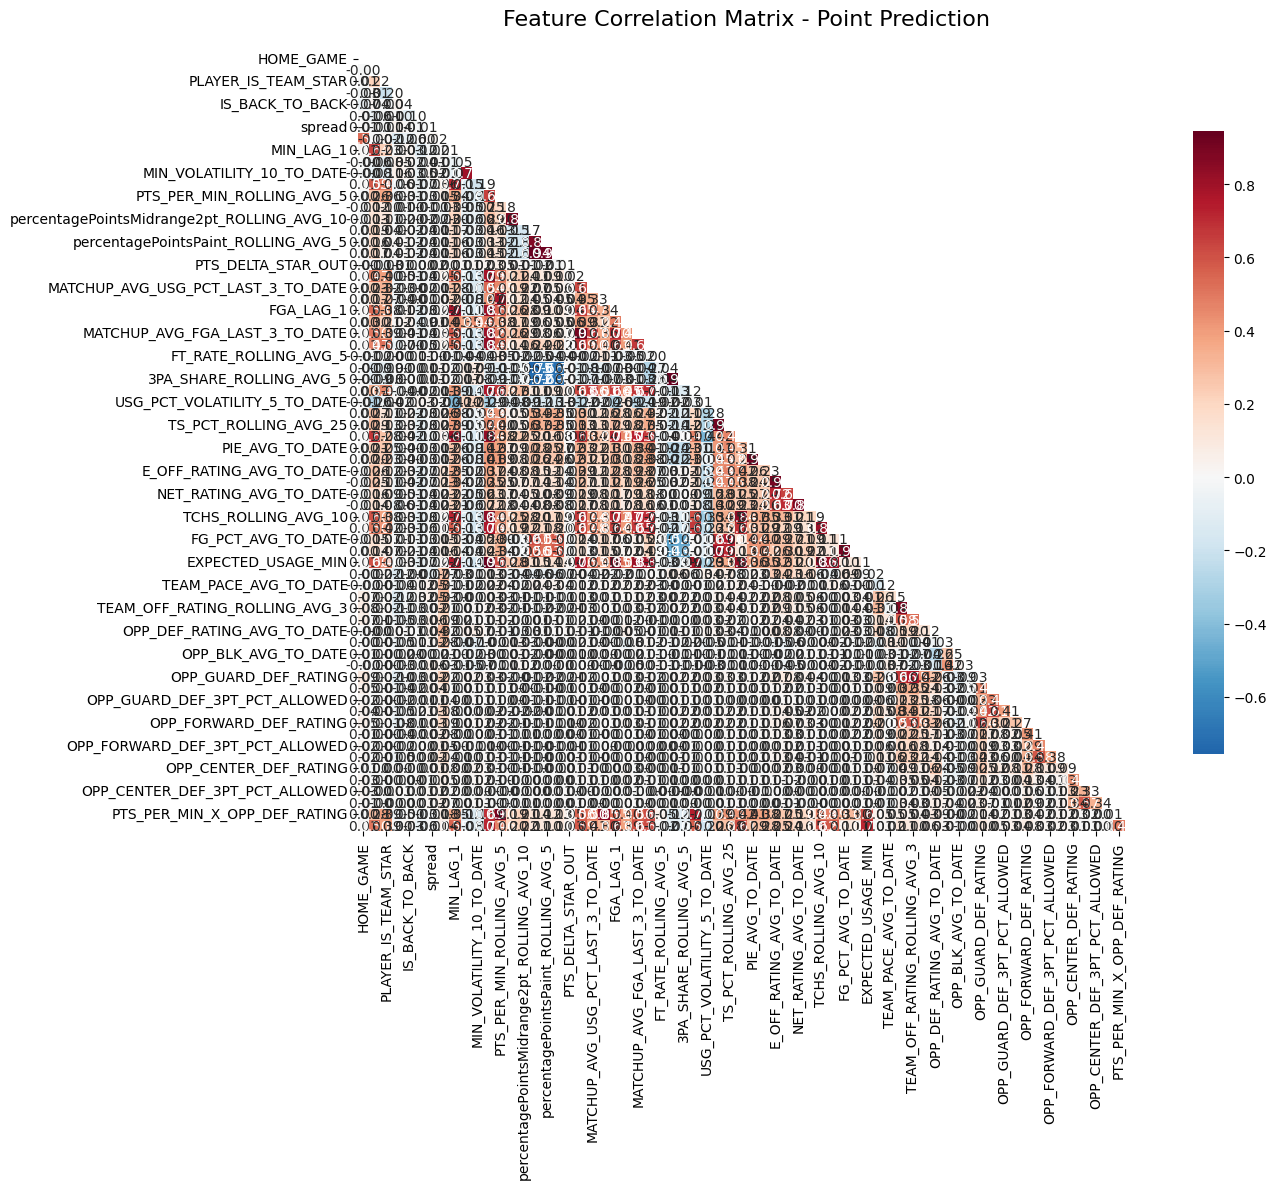

TOP 10 FEATURES MOST CORRELATED WITH PTS:
 1. PTS_ROLLING_AVG_15             0.715
 2. EXPECTED_USAGE_MIN             0.710
 3. FGA_LAG_1                      0.631
 4. TCHS_ROLLING_AVG_10            0.618
 5. FTA_ROLLING_AVG_40             0.617
 6. POSS_ROLLING_AVG_25            0.611
 7. MATCHUP_AVG_FGA_LAST_3_TO_DATE 0.610
 8. MATCHUP_AVG_PTS_LAST_3_TO_DATE 0.586
 9. TOV_ROLLING_AVG_10             0.575
10. USG_PCT_ROLLING_AVG_25         0.565

SUMMARY:
Original features: 69
Removed features: 0
Final features: 67


In [5]:
corr_matrix, top_10_features = correlation_analysis(train_df, top_features)

top_features = remove_highly_correlated_features(train_df, top_features, threshold=0.95)

### Train xgboost model and also using quantile regression

In [6]:
# Standard regression
xgbModel, metrics, _ = fit_train_val(
    train_df, val_df,
    features=top_features,
    target_col="PTS",
    date_col="GAME_DATE",
    player_col="PLAYER_ID",
    use_gpu=False,  
    tune_hyperparams=False,
    tune_iters=200
)

# Quantile regression
xgbModels, val_metrics = fit_quantile_models(
    train_df, val_df,
    features=top_features,
    target_col="PTS",
    date_col="GAME_DATE",
    player_col="PLAYER_ID",
    use_gpu=False
)

# Make predictions with quantile models
pred_df = predict_quantiles(xgbModels, test_df, top_features)

# Evaluate quantile models
test_results = evaluate_quantile_models(xgbModels, test_df, top_features, "PTS")

print("=" * 50)
print("STANDARD REGRESSION RESULTS")
print(f"VAL RMSE: {metrics['RMSE']:.2f}")
print(f"VAL MAE: {metrics['MAE']:.2f}")
print(f"VAL R²: {metrics['R2']:.2f}")

print("\n" + "=" * 50)
print("QUANTILE REGRESSION RESULTS")
for quantile_name, results in test_results.items():
    print(f"{quantile_name} Test RMSE: {results['RMSE']:.2f}")
    print(f"{quantile_name} Test MAE: {results['MAE']:.2f}")
    print(f"{quantile_name} Test R²: {results['R2']:.2f}")


Training quantile model for q10...
q10 validation RMSE: 8.962

Training quantile model for q50...
q50 validation RMSE: 5.730

Training quantile model for q90...
q90 validation RMSE: 8.925
q10 Test RMSE: 9.048
q50 Test RMSE: 5.880
q90 Test RMSE: 9.292
STANDARD REGRESSION RESULTS
VAL RMSE: 5.69
VAL MAE: 4.35
VAL R²: 0.60

QUANTILE REGRESSION RESULTS
q10 Test RMSE: 9.05
q10 Test MAE: 6.88
q10 Test R²: -0.06
q50 Test RMSE: 5.88
q50 Test MAE: 4.45
q50 Test R²: 0.55
q90 Test RMSE: 9.29
q90 Test MAE: 7.88
q90 Test R²: -0.12


### Evaluate pinball loss on out-of-time data

In [7]:
validate_by_position_pinball_loss(xgbModels, test_df, top_features, 'PTS')

PINBALL LOSS BY POSITION

GUARD (n=13521):
  q10: 0.9173
  q50: 2.3290
  q90: 1.1651

FORWARD (n=10139):
  q10: 0.8379
  q50: 2.1286
  q90: 1.0820

CENTER (n=2604):
  q10: 0.7892
  q50: 2.0431
  q90: 1.0378


### Plot SHAP values per position to verify the model leans on the right drivers

QUANTILE SHAP ANALYSIS BY POSITION

Q10 MODEL:
------------------------------
Top 10 Features:
  PTS_ROLLING_AVG_15             1.3123
  STARTING                       0.9282
  EXPECTED_USAGE_MIN             0.8366
  POSS_ROLLING_AVG_25            0.2011
  MIN_LAG_1                      0.1940
  PTS_PER_MIN_X_USG              0.1570
  TEAM_PTS_ROLLING_AVG_3         0.1542
  FGA_LAG_1                      0.1452
  PTS_PER_MIN_X_OPP_DEF_RATING   0.1369
  OPP_GUARD_DEF_RATING           0.1332
  FTA_ROLLING_AVG_40             0.1164
  TEAM_OFF_RATING_ROLLING_AVG_3  0.0797
  PLAYER_IS_TEAM_STAR            0.0668
  MATCHUP_AVG_PTS_LAST_3_TO_DATE 0.0652
  TCHS_ROLLING_AVG_10            0.0583

By Position:
  GUARD (n=13521): PTS_ROLLING_AVG_15 (1.409)
  FORWARD (n=10139): PTS_ROLLING_AVG_15 (1.230)
  CENTER (n=2604): PTS_ROLLING_AVG_15 (1.133)


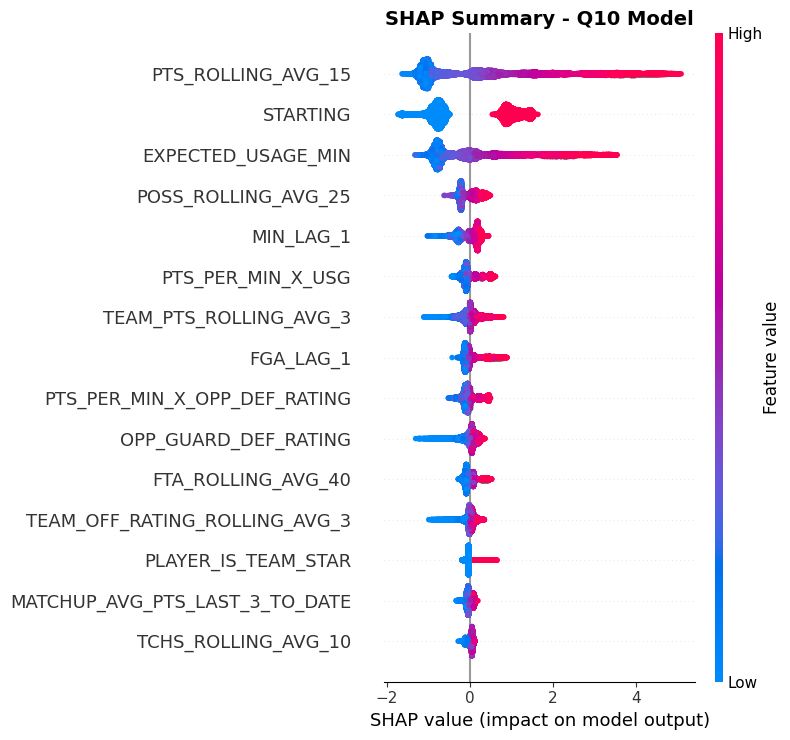


Q50 MODEL:
------------------------------
Top 10 Features:
  PTS_ROLLING_AVG_15             2.1439
  EXPECTED_USAGE_MIN             1.1789
  STARTING                       1.0903
  MIN_LAG_1                      0.3377
  STAR_SAT_OUT                   0.3357
  POSS_ROLLING_AVG_25            0.3282
  TEAM_PTS_ROLLING_AVG_3         0.3238
  PTS_PER_MIN_X_USG              0.2447
  PTS_PER_MIN_X_OPP_DEF_RATING   0.2377
  OPP_GUARD_DEF_RATING           0.2367
  FGA_LAG_1                      0.2141
  PTS_DELTA_STAR_OUT             0.1363
  FTA_ROLLING_AVG_40             0.1124
  USG_PCT_ROLLING_AVG_25         0.1117
  PLAYER_IS_TEAM_STAR            0.1090

By Position:
  GUARD (n=13521): PTS_ROLLING_AVG_15 (2.294)
  FORWARD (n=10139): PTS_ROLLING_AVG_15 (2.012)
  CENTER (n=2604): PTS_ROLLING_AVG_15 (1.881)


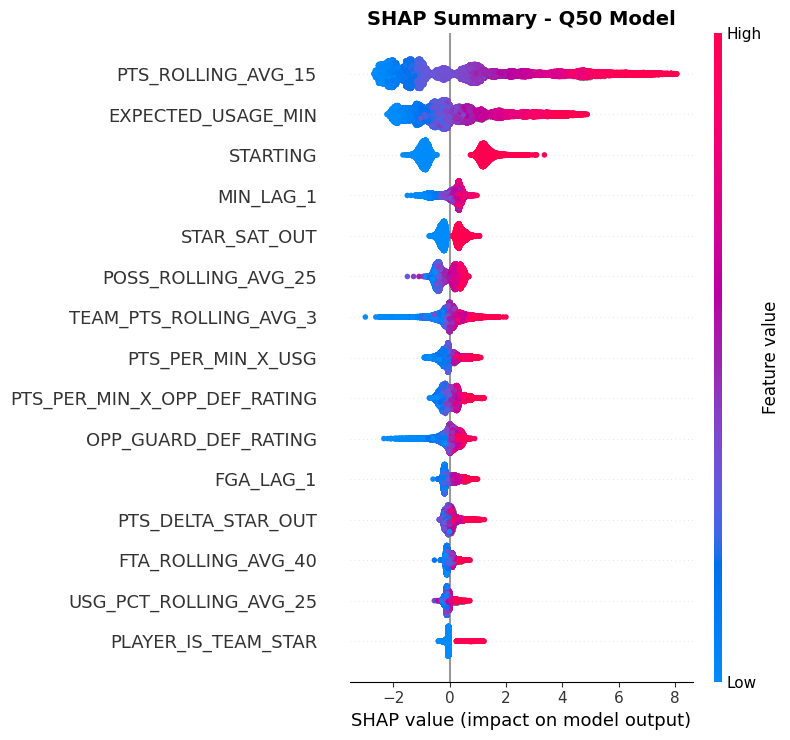


Q90 MODEL:
------------------------------
Top 10 Features:
  PTS_ROLLING_AVG_15             2.2764
  EXPECTED_USAGE_MIN             1.7505
  STARTING                       1.3182
  FGA_LAG_1                      0.5067
  STAR_SAT_OUT                   0.4765
  TEAM_PTS_ROLLING_AVG_3         0.4759
  PTS_PER_MIN_X_USG              0.3428
  PTS_PER_MIN_X_OPP_DEF_RATING   0.2786
  MIN_LAG_1                      0.2736
  OPP_GUARD_DEF_RATING           0.2728
  POSS_ROLLING_AVG_25            0.1970
  PTS_DELTA_STAR_OUT             0.1846
  MATCHUP_AVG_FGA_LAST_3_TO_DATE 0.1809
  USG_PCT_ROLLING_AVG_25         0.1778
  FTA_ROLLING_AVG_40             0.1622

By Position:
  GUARD (n=13521): PTS_ROLLING_AVG_15 (2.426)
  FORWARD (n=10139): PTS_ROLLING_AVG_15 (2.160)
  CENTER (n=2604): PTS_ROLLING_AVG_15 (1.951)


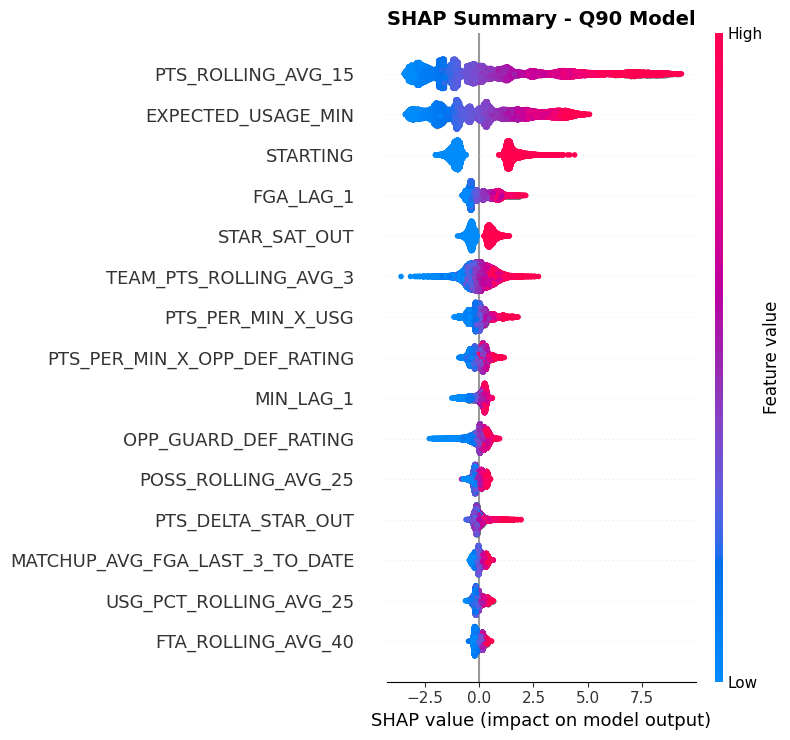

{'q10': XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6460723242676091, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='quantile', feature_types=None, feature_weights=None,
              gamma=0.7327236865873834, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01412139968434072,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=378, n_jobs=-1,
              num_parallel_tree=None, ...),
 'q50': XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6460723

In [8]:
analyze_quantile_shap(xgbModels, test_df, top_features, 'PTS')

### Check top 20 highest residuals

In [9]:
residuals_df = get_quantile_residuals(xgbModels, test_df, top_features, 'PTS')
residuals_df.sort_values('residual_q50', ascending=False).head(10)

,actual,pred_q10,pred_q50,pred_q90,residual_q10,residual_q50,residual_q90,PLAYER_NAME,MATCHUP,TEAM_PTS,OPP_PTS,STARTING,MIN,GUARD,FORWARD,CENTER,interval_width,within_80_interval,within_50_interval
5783,55,11.605656,19.272419,28.578089,43.394344,35.727581,26.421911,Jamal Murray,DEN vs. POR,132,121.0,1,42.23,1,0,0,16.972433,False,False
11327,43,2.220050,7.413312,15.003190,40.779950,35.586688,27.996810,Pat Connaughton,MIL vs. DET,140,133.0,1,43.57,1,0,0,12.783140,False,False
18398,60,16.006044,24.861860,34.532276,43.993956,35.138140,25.467724,De'Aaron Fox,SAC vs. MIN,126,130.0,1,44.48,1,0,0,18.526232,False,False
5995,61,18.583603,28.522009,37.392139,42.416397,32.477991,23.607861,Nikola Jokić,DEN vs. MIN,139,140.0,1,52.63,0,0,1,18.808537,False,False
1448,43,3.201982,10.878803,18.894005,39.798018,32.121197,24.105995,Payton Pritchard,BOS vs. POR,128,118.0,0,42.85,1,0,0,15.692023,False,False
10431,41,2.367179,9.328586,18.344299,38.632821,31.671414,22.655701,Jaime Jaquez Jr.,MIA vs. WAS,118,119.0,1,40.53,1,0,0,15.977120,False,False
6741,56,13.702196,24.487926,35.110111,42.297804,31.512074,20.889889,Stephen Curry,GSW @ ORL,121,115.0,1,34.30,1,0,0,21.407915,False,False
11656,53,12.668996,21.805519,29.863995,40.331004,31.194481,23.136005,Anthony Edwards,MIN @ DET,105,119.0,1,44.45,1,0,0,17.195000,False,False
20598,41,3.342054,10.062709,18.060804,37.657946,30.937291,22.939196,Aaron Wiggins,OKC vs. SAC,144,110.0,1,39.88,1,0,0,14.718750,False,False
16280,44,5.910535,14.062211,25.531435,38.089465,29.937789,18.468565,Quentin Grimes,PHI vs. GSW,126,119.0,1,36.72,1,0,0,19.620899,False,False


In [10]:
# Calibrate predicted intervals with isotonic regression or conformal quantiles.
# Betting Layer
# Convert quantiles to normal or skewed-t distribution. Estimate μ = q50, σ ≈ (q90 − q10)/2.56.

# Compute P(over line) for each offered prop.

# Edge = P(model_over) − P(book_over)

# Bet only if Edge > 0.05 (5%) and Kelly_fraction = Edge / Odds_edge_ratio (use 0.25×Kelly).

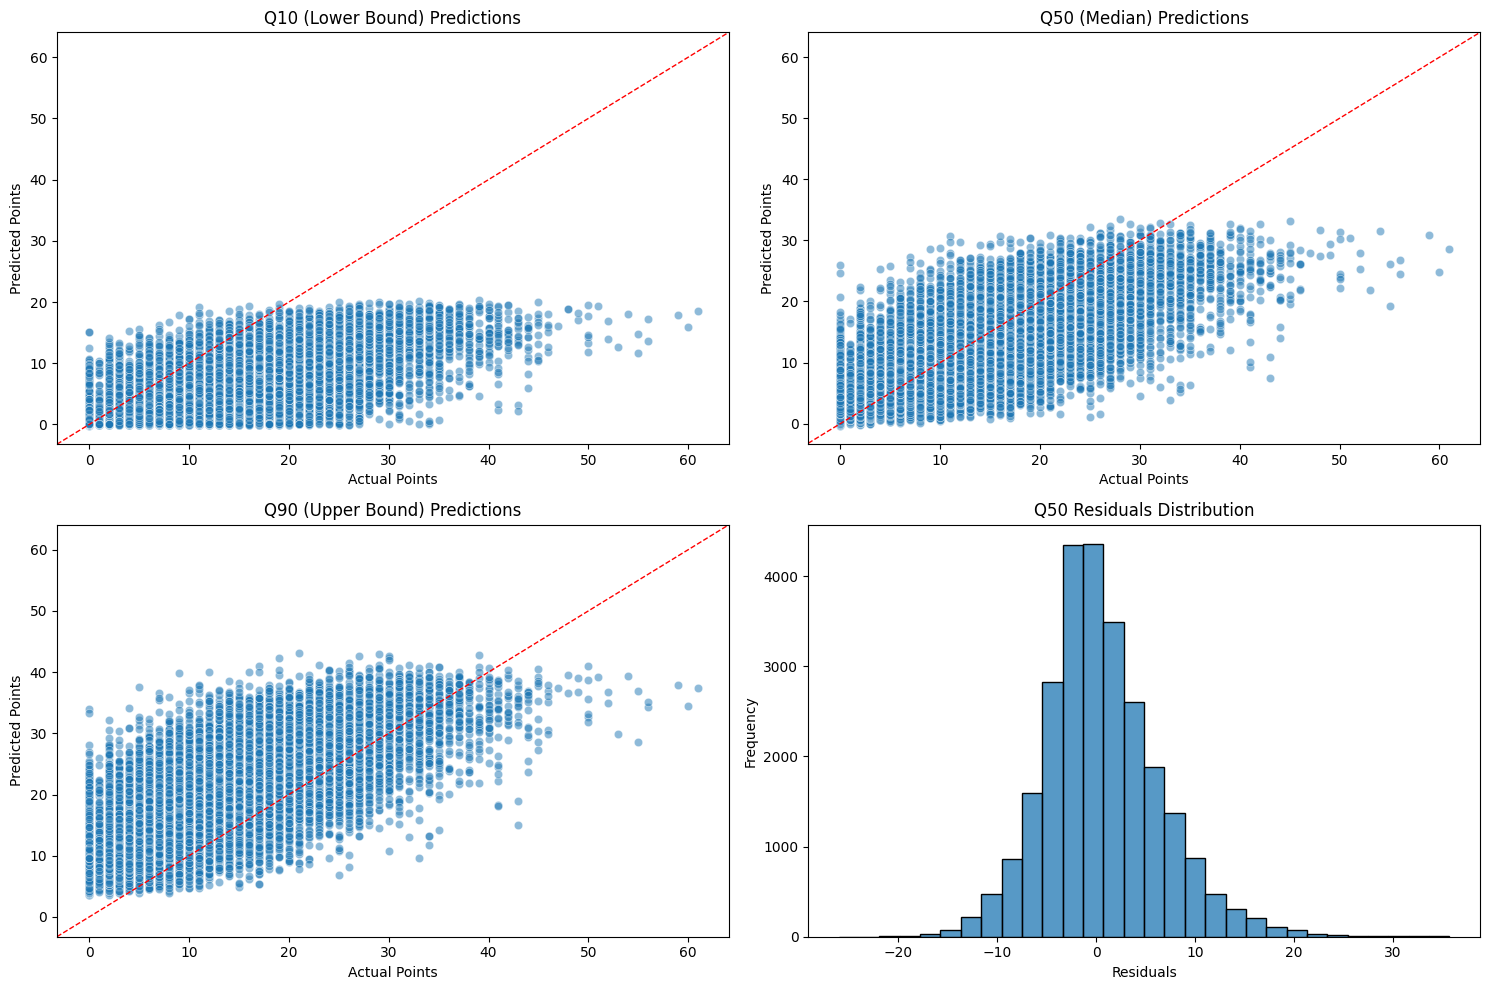

In [11]:
# Enhanced quantile prediction plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Q10 predictions
sns.scatterplot(x='actual', y='pred_q10', data=residuals_df, alpha=0.5, ax=axes[0,0])
minVal = min(residuals_df['actual'].min(), residuals_df['pred_q10'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['pred_q10'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_title('Q10 (Lower Bound) Predictions')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

# Q50 predictions  
sns.scatterplot(x='actual', y='pred_q50', data=residuals_df, alpha=0.5, ax=axes[0,1])
minVal = min(residuals_df['actual'].min(), residuals_df['pred_q10'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['pred_q10'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_title('Q50 (Median) Predictions')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

# Q90 predictions
sns.scatterplot(x='actual', y='pred_q90', data=residuals_df, alpha=0.5, ax=axes[1,0])
minVal = min(residuals_df['actual'].min(), residuals_df['pred_q10'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['pred_q10'].max())
axes[1,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[1,0].set_title('Q90 (Upper Bound) Predictions')
axes[1,0].set_xlabel('Actual Points')
axes[1,0].set_ylabel('Predicted Points')

# Residuals distribution
sns.histplot(residuals_df['residual_q50'], bins=30, ax=axes[1,1])
axes[1,1].set_title('Q50 Residuals Distribution')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

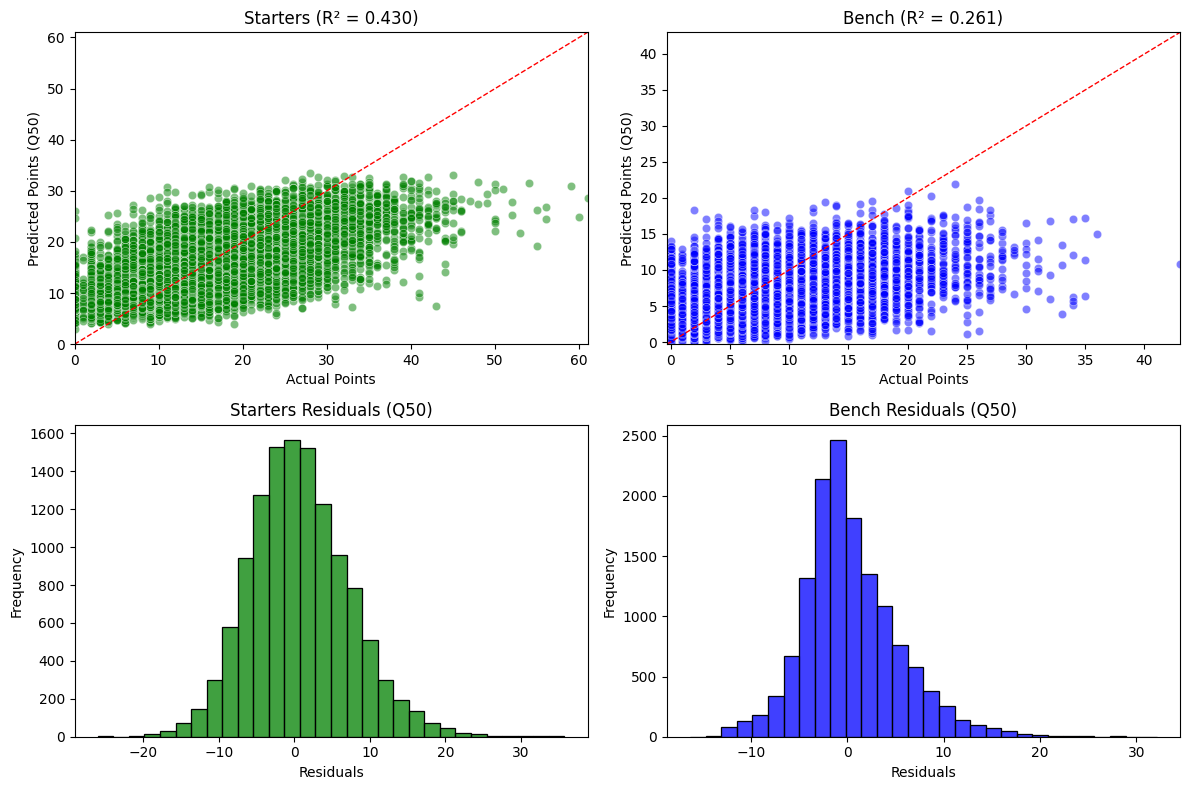

In [12]:
# Get quantile residuals first
residuals_df = get_quantile_residuals(xgbModels, test_df, top_features, 'PTS')

# Split by starting status
starters = residuals_df[residuals_df['STARTING'] == 1] 
bench = residuals_df[residuals_df['STARTING'] == 0]

# Calculate R² for Q50 (median) predictions
from sklearn.metrics import r2_score
starters_r2 = r2_score(starters['actual'], starters['pred_q50'])
bench_r2 = r2_score(bench['actual'], bench['pred_q50'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 

# Starters scatter plot
sns.scatterplot(x='actual', y='pred_q50', data=starters, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starters['actual'].min(), starters['pred_q50'].min())
maxVal = max(starters['actual'].max(), starters['pred_q50'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Starters (R² = {starters_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points (Q50)')

# Bench scatter plot
sns.scatterplot(x='actual', y='pred_q50', data=bench, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(bench['actual'].min(), bench['pred_q50'].min())
maxVal = max(bench['actual'].max(), bench['pred_q50'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Bench (R² = {bench_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points (Q50)')

# Starters residuals
sns.histplot(starters['residual_q50'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Starters Residuals (Q50)')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

# Bench residuals
sns.histplot(bench['residual_q50'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Bench Residuals (Q50)')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()

In [16]:
joblib.dump(xgbModels['q10'], 'SAVED_MODELS/xgb_q10_modelv1.pkl')
joblib.dump(xgbModels['q50'], 'SAVED_MODELS/xgb_q50_modelv1.pkl')
joblib.dump(xgbModels['q90'], 'SAVED_MODELS/xgb_q90_modelv1.pkl')
joblib.dump(top_features, 'SAVED_MODELS/feature_list.pkl')

['SAVED_MODELS/feature_list.pkl']